## Ride Fare Surge Analysis on Fare Volatility of UBER & LYFT services baseed in Boston

## Step 1: Initialization- Libraries and Data Loading

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [69]:
# Import cab rides dataset
df_rides = pd.read_csv(r'Data\cab_rides.csv')

# Import weather dataset
df_weather  = pd.read_csv(r'Data\weather.csv')

In [70]:
df_rides

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL
...,...,...,...,...,...,...,...,...,...,...
693066,1.00,Uber,1543708385534,North End,West End,13.0,1.0,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
693067,1.00,Uber,1543708385534,North End,West End,9.5,1.0,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
693068,1.00,Uber,1543708385534,North End,West End,NaN,1.0,64d451d0-639f-47a4-9b7c-6fd92fbd264f,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
693069,1.00,Uber,1543708385534,North End,West End,27.0,1.0,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV


In [71]:
df_weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.00,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.00,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.00,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.00,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.00,1012.14,0.1786,1545003901,0.75,11.49
...,...,...,...,...,...,...,...,...
6271,44.72,North Station,0.89,1000.69,NaN,1543819974,0.96,1.52
6272,44.85,Northeastern University,0.88,1000.71,NaN,1543819974,0.96,1.54
6273,44.82,South Station,0.89,1000.70,NaN,1543819974,0.96,1.54
6274,44.78,Theatre District,0.89,1000.70,NaN,1543819974,0.96,1.54


## Step 2: Data Preprocessing

### 2.1 Unifing timestamp format and turn to datetime

In [72]:
df_rides['date_time'] = pd.to_datetime(df_rides['time_stamp']/1000, unit='s')
df_weather['date_time'] = pd.to_datetime(df_weather['time_stamp'], unit='s')

### 2.2 Merging info location-date-hour wise

In [73]:
df_rides['loc_date_hr'] = df_rides['source'].astype(str) + " - " + df_rides['date_time'].dt.date.astype(str) + " - " + df_rides['date_time'].dt.hour.astype(str)
df_weather['loc_date_hr'] = df_weather['location'].astype(str) + " - " + df_weather['date_time'].dt.date.astype(str) + " - " + df_weather['date_time'].dt.hour.astype(str)

In [74]:
df_weather

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind,date_time,loc_date_hr
0,42.42,Back Bay,1.00,1012.14,0.1228,1545003901,0.77,11.25,2018-12-16 23:45:01,Back Bay - 2018-12-16 - 23
1,42.43,Beacon Hill,1.00,1012.15,0.1846,1545003901,0.76,11.32,2018-12-16 23:45:01,Beacon Hill - 2018-12-16 - 23
2,42.50,Boston University,1.00,1012.15,0.1089,1545003901,0.76,11.07,2018-12-16 23:45:01,Boston University - 2018-12-16 - 23
3,42.11,Fenway,1.00,1012.13,0.0969,1545003901,0.77,11.09,2018-12-16 23:45:01,Fenway - 2018-12-16 - 23
4,43.13,Financial District,1.00,1012.14,0.1786,1545003901,0.75,11.49,2018-12-16 23:45:01,Financial District - 2018-12-16 - 23
...,...,...,...,...,...,...,...,...,...,...
6271,44.72,North Station,0.89,1000.69,NaN,1543819974,0.96,1.52,2018-12-03 06:52:54,North Station - 2018-12-03 - 6
6272,44.85,Northeastern University,0.88,1000.71,NaN,1543819974,0.96,1.54,2018-12-03 06:52:54,Northeastern University - 2018-12-03 - 6
6273,44.82,South Station,0.89,1000.70,NaN,1543819974,0.96,1.54,2018-12-03 06:52:54,South Station - 2018-12-03 - 6
6274,44.78,Theatre District,0.89,1000.70,NaN,1543819974,0.96,1.54,2018-12-03 06:52:54,Theatre District - 2018-12-03 - 6


### 2.3 Grouping the weather by the location and datetime and updating corresponding parameters with mean value.

In [75]:
weather = df_weather.groupby(['loc_date_hr']).agg({'temp': 'mean', 'clouds': 'mean', 'pressure': 'mean', 'rain': 'mean', 'humidity': 'mean', 'wind': 'mean'}).reset_index()
weather['location'] = df_weather.groupby(['loc_date_hr'])['location'].first().values
weather.index = weather['loc_date_hr']
weather['rain'].fillna(0)

loc_date_hr
Back Bay - 2018-11-26 - 10    0.0000
Back Bay - 2018-11-26 - 11    0.0000
Back Bay - 2018-11-26 - 12    0.0000
Back Bay - 2018-11-26 - 13    0.0062
Back Bay - 2018-11-26 - 14    0.0088
                               ...  
West End - 2018-12-18 - 5     0.0371
West End - 2018-12-18 - 6     0.0000
West End - 2018-12-18 - 7     0.0000
West End - 2018-12-18 - 8     0.0000
West End - 2018-12-18 - 9     0.0000
Name: rain, Length: 3960, dtype: float64

In [76]:
#Merging the both dataset into one using on 'loc_date_hr'
merged_df = df_rides.join(weather,on=['loc_date_hr'],rsuffix ='_w')
merged_df.dropna(inplace=True)

In [77]:
#getting hour as separate feature
merged_df['hour'] = merged_df['date_time'].dt.hour.astype(int)
def categorize_time(hour):
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 22:
        return 'Night'
    elif hour == 23 or hour == 0 or hour == 1:
        return 'Late Night'
    elif 2 <= hour <= 5:
        return 'Late Night'

merged_df['day_time'] = merged_df['hour'].apply(categorize_time)

In [78]:
merged_df.info()

<class 'pandas.DataFrame'>
Index: 109152 entries, 1 to 693058
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   distance          109152 non-null  float64       
 1   cab_type          109152 non-null  str           
 2   time_stamp        109152 non-null  int64         
 3   destination       109152 non-null  str           
 4   source            109152 non-null  str           
 5   price             109152 non-null  float64       
 6   surge_multiplier  109152 non-null  float64       
 7   id                109152 non-null  str           
 8   product_id        109152 non-null  str           
 9   name              109152 non-null  str           
 10  date_time         109152 non-null  datetime64[ns]
 11  loc_date_hr       109152 non-null  str           
 12  loc_date_hr_w     109152 non-null  str           
 13  temp              109152 non-null  float64       
 14  clouds            10

#### 
NOTE:- This information tells it does not contain any nulls and missing values.

In [79]:
merged_df.drop(columns=['id', 'product_id', 'time_stamp', 'location', 
                        'date_time', 'loc_date_hr', 'loc_date_hr_w', 'hour'], 
               inplace=True)

In [80]:
merged_df.head()

,distance,cab_type,destination,source,price,surge_multiplier,name,temp,clouds,pressure,rain,humidity,wind,day_time
1,0.44,Lyft,North Station,Haymarket Square,11.0,1.0,Lux,44.065,0.995,1002.880,0.10600,0.895,12.630,Late Night
9,1.08,Lyft,Northeastern University,Back Bay,27.5,1.0,Lux Black XL,44.755,0.990,990.825,0.01500,0.965,6.005,Morning
15,1.11,Uber,West End,North End,7.5,1.0,WAV,42.360,1.000,1012.150,0.20880,0.770,11.460,Late Night
23,0.72,Lyft,Haymarket Square,North Station,26.0,1.0,Lux Black XL,42.350,0.910,1018.920,0.01000,0.730,9.440,Afternoon
32,3.24,Lyft,Northeastern University,North Station,3.5,1.0,Shared,44.215,0.995,1001.155,0.20185,0.895,13.050,Late Night


## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Distribution of Ride Prices
We utilize a histogram overlaid with a Kernel Density Estimate (KDE) to visualize the frequency and smooth probability density of Uber & Lyft fares across Boston.

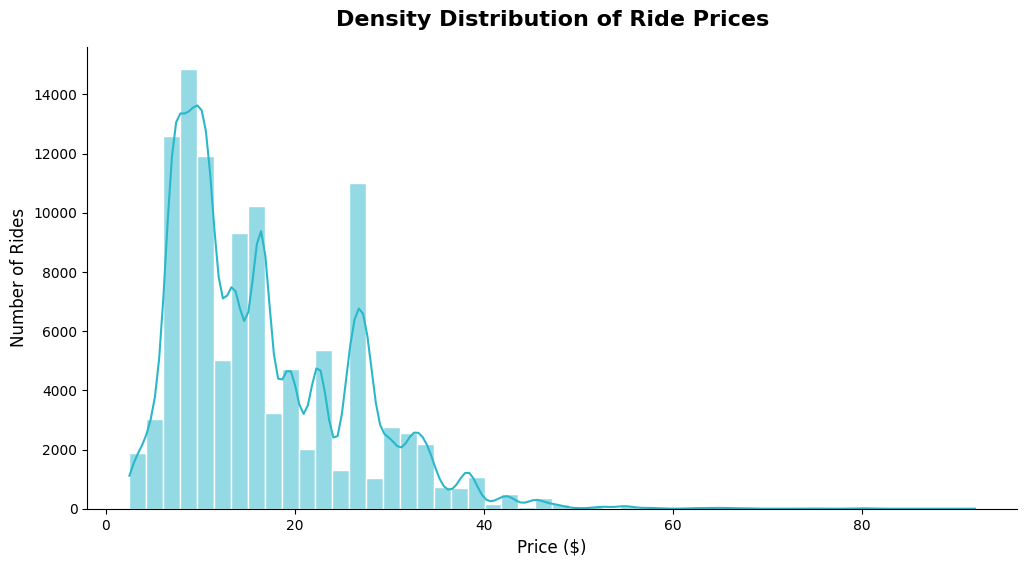

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Histplot with KDE shows both frequency and smooth density
sns.histplot(data=merged_df, x='price', bins=50, kde=True, color='#2ab7ca', edgecolor='white')

plt.title('Density Distribution of Ride Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
sns.despine()

plt.show()

### 3.2 Outlier Detection and Variance Analysis
To better understand the spread of ride fares and the impact of surge pricing, we visualize the data using a Box Plot. Due to the presence of high-value outliers in the Boston dataset, we apply a Logarithmic Scale to the x-axis. 

This transformation ensures that the central distribution (the bulk of the rides) remains legible while still accounting for extreme price surges.

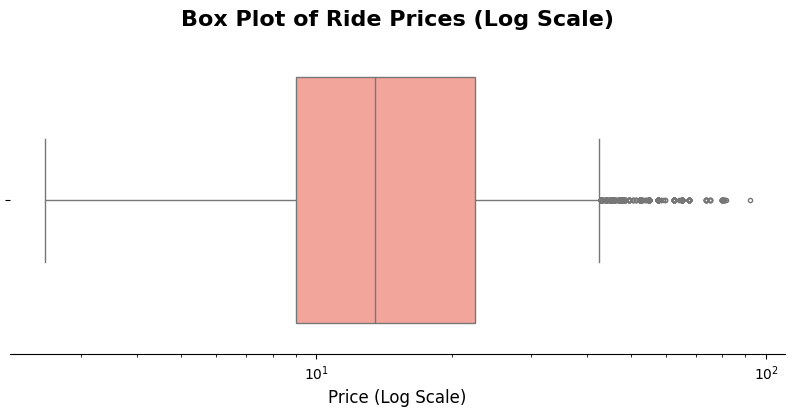

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

sns.boxplot(x=merged_df['price'], color='#ff9a8d', fliersize=3) # fliersize makes outlier dots smaller

plt.xscale('log') # This is the magic line that fixes the squish

plt.title('Box Plot of Ride Prices (Log Scale)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price (Log Scale)', fontsize=12)
sns.despine(left=True)

plt.show()

####
NOTE:-  From the box plot, we can conclude that most ride prices are relatively low, with a few rides being significantly more expensive, indicative of outliers or premium pricing.

## Step 4:- Data Refinement - Outlier Removal

### 4.1 Mathematical Implementation
We define outliers as any data point falling $1.5 \times IQR$ below the first quartile or above the third quartile.

In [83]:
# Calculate the first and third quartiles
Q1 = merged_df['price'].quantile(0.25)
Q3 = merged_df['price'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to exclude outliers
filtered_df = merged_df[(merged_df['price'] >= lower_bound) & (merged_df['price'] <= upper_bound)]

# Display the filtered DataFrame without outliers
print("Original DataFrame shape:", merged_df.shape)
print("Filtered DataFrame shape (without outliers):", filtered_df.shape)


Original DataFrame shape: (109152, 14)
Filtered DataFrame shape (without outliers): (108201, 14)


## Step 5: Market Share Analysis - Cab Type Distribution

To ensure a balanced comparative analysis, we examine the distribution of our categorical target variable: Cab Type. Verifying the proportion of Uber vs. Lyft rides allows us to confirm that our dataset provides an equitable representation of both major ride-hailing platforms in the Boston area.

### 5.1 Visualizing Provider Proportions
We use a normalized bar plot to visualize the market split, ensuring that our model training won't be biased toward a dominant class.

C:\Users\Ashish\AppData\Local\Temp\ipykernel_4124\1268115600.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_distribution.index, y=target_distribution.values, palette='viridis')


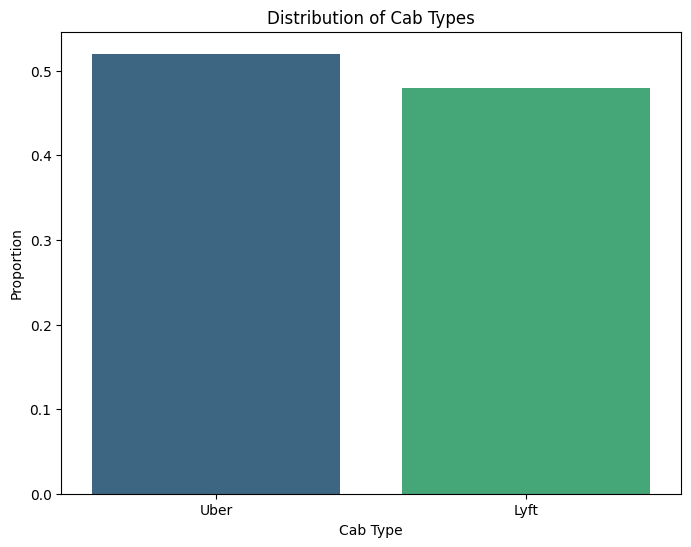

Percentage of Uber rides: 52.01
Percentage of Lyft rides: 47.99


In [84]:
# Check the distribution of the target variable
target_distribution = merged_df['cab_type'].value_counts(normalize=True)

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=target_distribution.index, y=target_distribution.values, palette='viridis')
plt.title('Distribution of Cab Types')
plt.xlabel('Cab Type')
plt.ylabel('Proportion')
plt.show()

# Print the distribution percentages
print("Percentage of Uber rides:", round(target_distribution['Uber'] * 100, 2))
print("Percentage of Lyft rides:", round(target_distribution['Lyft'] * 100, 2))


### 
NOTE;- The bar chart displays the proportion of rides for Uber and Lyft. Both bars are quite similar in height, suggesting a balanced distribution between the two cab types. There doesn't appear to be a significant imbalance issue based on this visualization; the proportions of Uber and Lyft rides in the dataset are almost equal.

## Step 6: Data Segmentation - Provider Specific Subsetting

To facilitate a granular comparative analysis, we partition the primary dataset into two distinct subsets: Uber and Lyft. 

### 6.1 Creating Provider DataFrames
We utilize the .copy() method during subsetting to ensure these new DataFrames are independent objects, preventing any SettingWithCopy warnings during subsequent transformations.

In [85]:
#Separating Cab services into Lyft and Uber
# Subsetting dataframe into uber and lyft
df_lyft = merged_df[merged_df['cab_type']=='Lyft'].copy()
df_uber = merged_df[merged_df['cab_type']=='Uber'].copy()

### 6.2 Defining X (Features) and y (Target)
We perform this split independently for both Uber and Lyft to allow for provider-specific model optimization.

In [86]:
#Separating features and target
X_lyft = df_lyft.drop('price',axis=1)
y_lyft = df_lyft['price'].copy()

X_uber = df_uber.drop('price',axis=1)
y_uber = df_uber['price'].copy()

In [87]:
X_lyft.head()

,distance,cab_type,destination,source,surge_multiplier,name,temp,clouds,pressure,rain,humidity,wind,day_time
1,0.44,Lyft,North Station,Haymarket Square,1.0,Lux,44.065,0.995,1002.880,0.10600,0.895,12.630,Late Night
9,1.08,Lyft,Northeastern University,Back Bay,1.0,Lux Black XL,44.755,0.990,990.825,0.01500,0.965,6.005,Morning
23,0.72,Lyft,Haymarket Square,North Station,1.0,Lux Black XL,42.350,0.910,1018.920,0.01000,0.730,9.440,Afternoon
32,3.24,Lyft,Northeastern University,North Station,1.0,Shared,44.215,0.995,1001.155,0.20185,0.895,13.050,Late Night
33,3.24,Lyft,Northeastern University,North Station,1.0,Lyft,48.340,0.990,1006.020,0.00300,0.940,4.110,Night


## Step 7:- Predictive Modeling for Fare Analysis

In [88]:
# Creating preprocessing pipeline
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [89]:
#Converting data into machine understandable language
str_attributes = ["cab_type", "destination", "source", "name", "day_time"]
num_attributes = ["distance", "temp", "clouds", "pressure", "rain", "humidity", "wind","surge_multiplier"]

pipeline = ColumnTransformer([
        ("str", OneHotEncoder(drop="first"), str_attributes),
        ("num", StandardScaler(), num_attributes),])

pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('str', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [90]:
from sklearn.model_selection import train_test_split
X_train_lyft, X_test_lyft, y_train_lyft, y_test_lyft = train_test_split(X_lyft, y_lyft, test_size=0.2, random_state=42)

X_train_lyft_prepared = pipeline.fit_transform(X_train_lyft)

### 7.1} Approach 1 - Random Forest Model
This method is particularly well-suited for the Boston dataset as it effectively captures non-linear relationships between features—such as the interplay between peak hours and weather conditions—without being overly sensitive to outliers.

#### 7.1.0: Automated Data Pipelining

In [91]:
#Training the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
model = make_pipeline(pipeline,RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X_train_lyft, y_train_lyft)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('str', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

#### 7.1.1: Random Forest Model for Lyft

In [92]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predict and calculate the metrics
y_pred = model.predict(X_test_lyft)

# Calculate Mean Squared Error and then take the square root for RMSE
mse = mean_squared_error(y_test_lyft, y_pred)
rmse = np.sqrt(mse)

# Calculate R^2 Score
r2 = r2_score(y_test_lyft, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 2.3730528770351142
Root Mean Squared Error: 1.54047164110058
R^2 Score: 0.9764119862469695


#### 7.1.2 Random forest Model for Uber

In [93]:
# Now, we can properly split the data
X_train_uber, X_test_uber, y_train_uber, y_test_uber = train_test_split(X_uber, y_uber, test_size=0.2, random_state=42)

In [94]:
# Transform the training data using the same pipeline as Lyft
X_train_uber_prepared = pipeline.fit_transform(X_train_uber)

In [95]:
# Using the same RandomForestRegressor for Uber
from sklearn.ensemble import RandomForestRegressor
model_uber = make_pipeline(pipeline, RandomForestRegressor(n_estimators=100, random_state=42))
model_uber.fit(X_train_uber, y_train_uber)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('str', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [96]:
# Predicting the prices for Uber
y_pred_uber = model_uber.predict(X_test_uber)

# Calculate Mean Squared Error and RMSE for Uber
mse_uber = mean_squared_error(y_test_uber, y_pred_uber)
rmse_uber = np.sqrt(mse_uber)

# Calculate R^2 Score for Uber
r2_uber = r2_score(y_test_uber, y_pred_uber)

print(f"Uber - Mean Squared Error: {mse_uber}")
print(f"Uber - Root Mean Squared Error: {rmse_uber}")
print(f"Uber - R^2 Score: {r2_uber}")

Uber - Mean Squared Error: 4.189087328503745
Uber - Root Mean Squared Error: 2.0467260023031284
Uber - R^2 Score: 0.9417453935284814


### 7.2} Approach 2 - Gradient Boosting

Unlike Random Forest, which relies on bagging, Gradient Boosting uses a boosting technique—training learners sequentially to minimize the residual errors of previous iterations. This often results in higher predictive accuracy for complex datasets like Boston's ride-share market.

#### 7.2.1 Gradient Boosting for Lyft

In [97]:
# By using gradientboosting model
from sklearn.ensemble import GradientBoostingRegressor

# Create a new model with GradientBoostingRegressor
model_gbr = make_pipeline(pipeline, GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))

# Training the model with Lyft data as an example
model_gbr.fit(X_train_lyft, y_train_lyft)
# Predicting the prices for Lyft
y_pred_lyft_gbr = model_gbr.predict(X_test_lyft)

In [98]:
# Calculate metrics for Lyft with Gradient Boosting Regressor
mse_lyft_gbr = mean_squared_error(y_test_lyft, y_pred_lyft_gbr)
rmse_lyft_gbr = np.sqrt(mse_lyft_gbr)
r2_lyft_gbr = r2_score(y_test_lyft, y_pred_lyft_gbr)

In [99]:
print(f"Gradient Boosting - Lyft - Mean Squared Error: {mse_lyft_gbr}")
print(f"Gradient Boosting - Lyft - Root Mean Squared Error: {rmse_lyft_gbr}")
print(f"Gradient Boosting - Lyft - R^2 Score: {r2_lyft_gbr}")

Gradient Boosting - Lyft - Mean Squared Error: 2.5302231969313573
Gradient Boosting - Lyft - Root Mean Squared Error: 1.5906675318655867
Gradient Boosting - Lyft - R^2 Score: 0.9748497219994434


#### 7.2.2 Gradient Boosting for Uber

In [100]:
# for Uber
model_gbr.fit(X_train_uber, y_train_uber)
y_pred_uber_gbr = model_gbr.predict(X_test_uber)

In [101]:
mse_uber_gbr = mean_squared_error(y_test_uber, y_pred_uber_gbr)
rmse_uber_gbr = np.sqrt(mse_uber_gbr)
r2_uber_gbr = r2_score(y_test_uber, y_pred_uber_gbr)


In [102]:
print(f"Gradient Boosting - Uber - Mean Squared Error: {mse_uber_gbr}")
print(f"Gradient Boosting - Uber - Root Mean Squared Error: {rmse_uber_gbr}")
print(f"Gradient Boosting - Uber - R^2 Score: {r2_uber_gbr}")

Gradient Boosting - Uber - Mean Squared Error: 4.3817124741470534
Gradient Boosting - Uber - Root Mean Squared Error: 2.0932540395630563
Gradient Boosting - Uber - R^2 Score: 0.9390666950015691


### 7.3} Approach 3 - K Nearest Neighbor Model
We implement the K-Nearest Neighbors (KNN) algorithm. This is a non-parametric, instance-based learning method that predicts the price of a ride by averaging the fares of the $k$ most similar historical records. In a dense urban environment like Boston, this can be highly effective for capturing localized pricing clusters in specific neighborhoods.

#### 7.3.1  K Nearest Neighbor Model for Uber

In [133]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# List of models to evaluate
models = {
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5),
}

# Splitting the data for Lyft
features_lyft = df_lyft.drop('price', axis=1)  
target_lyft = df_lyft['price']
X_train_lyft, X_test_lyft, y_train_lyft, y_test_lyft = train_test_split(features_lyft, target_lyft, test_size=0.2, random_state=42)

# Splitting the data for Uber
features_uber = df_uber.drop('price', axis=1) 
target_uber = df_uber['price']
X_train_uber, X_test_uber, y_train_uber, y_test_uber = train_test_split(features_uber, target_uber, test_size=0.2, random_state=42)

from sklearn.preprocessing import OneHotEncoder
# One-hot encode categorical features for Uber

encoder = OneHotEncoder(drop='first', handle_unknown="ignore")
X_train_uber_encoded = encoder.fit_transform(X_train_uber)
X_test_uber_encoded = encoder.transform(X_test_uber)
# Apply each model to both Lyft and Uber datasets
for model_name, model in models.items():
    print(f"Applying {model_name}:")

    
    # Evaluate for Uber
    evaluate_model(model_name, model, X_train_uber_encoded, y_train_uber, X_test_uber_encoded, y_test_uber, "Uber")


c:\Users\Ashish\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Applying K-Nearest Neighbors:
K-Nearest Neighbors - Uber - Mean Squared Error: 42.50119594892118
K-Nearest Neighbors - Uber - Root Mean Squared Error: 6.519294129652471
K-Nearest Neighbors - Uber - R² Score: 0.4089666195959587


#### 7.3.2  K Nearest Neighbor Model for Lyft

In [104]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test, dataset_name):
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict using the model
    y_pred = model.predict(X_test)
    
    # Calculate Mean Squared Error and then take the square root for RMSE
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # Calculate R^2 Score
    r2 = r2_score(y_test, y_pred)
    
    # Print the evaluation metrics
    print(f"{model_name} - {dataset_name} - Mean Squared Error: {mse}")
    print(f"{model_name} - {dataset_name} - Root Mean Squared Error: {rmse}")
    print(f"{model_name} - {dataset_name} - R² Score: {r2}")

# Example usage:
# Assuming `models` is a dictionary of sklearn model instances
from sklearn.preprocessing import OneHotEncoder

# One-hot encode categorical features
encoder = OneHotEncoder(drop='first', handle_unknown="ignore")
X_train_lyft_encoded = encoder.fit_transform(X_train_lyft)
X_test_lyft_encoded = encoder.transform(X_test_lyft)

# Apply each model to the Lyft dataset
for model_name, model in models.items():
    print(f"Applying {model_name}:")
    evaluate_model(model_name, model, X_train_lyft_encoded, y_train_lyft, X_test_lyft_encoded, y_test_lyft, "Lyft")

c:\Users\Ashish\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Applying K-Nearest Neighbors:
K-Nearest Neighbors - Lyft - Mean Squared Error: 50.27424207712867
K-Nearest Neighbors - Lyft - Root Mean Squared Error: 7.090433137483822
K-Nearest Neighbors - Lyft - R² Score: 0.5002768269453319


### 7.4 Visual Model Evaluation and Comparative Analysis (Scope:- Fare)

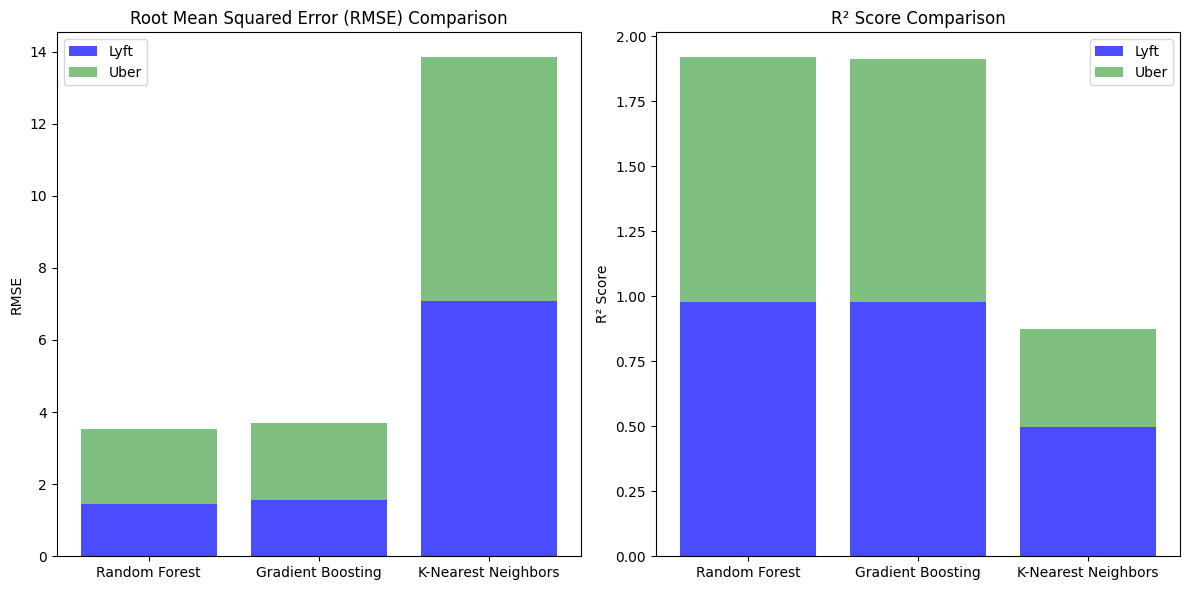

In [106]:
import matplotlib.pyplot as plt

# Data for plotting
models = ['Random Forest', 'Gradient Boosting', 'K-Nearest Neighbors']
rmse_lyft = [1.439, 1.563, 7.071]
r2_lyft = [0.979, 0.976, 0.499]
rmse_uber = [2.102, 2.127, 6.771]
r2_uber = [0.940, 0.938, 0.374]

# Plotting the Root Mean Squared Error (RMSE)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(models, rmse_lyft, color='blue', alpha=0.7, label='Lyft')
plt.bar(models, rmse_uber, color='green', alpha=0.5, label='Uber', bottom=rmse_lyft)
plt.title('Root Mean Squared Error (RMSE) Comparison')
plt.ylabel('RMSE')
plt.legend()

# Plotting the R² Scores
plt.subplot(1, 2, 2)
plt.bar(models, r2_lyft, color='blue', alpha=0.7, label='Lyft')
plt.bar(models, r2_uber, color='green', alpha=0.5, label='Uber', bottom=r2_lyft)
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.legend()

plt.tight_layout()
plt.show()


### -> Report Card - Fare Analysis
For both Lyft and Uber, the Random Forest Regressor shows the lowest RMSE and the highest R² Score, making it the best model among the ones evaluated based on these metrics.

## Step 8:-  Problem 2: Predictive Modeling for Rain Impact on Uber and Lyft datasets

#### Step 8.0.1 Strategic Feature Selection for Weather Impact Analysis

In [107]:
# Step 1: Create a new DataFrame with relevant columns
weather_impact_df = merged_df[['cab_type', 'destination', 'source', 'name', 'day_time','price', 'rain']].copy()

# Step 2: Separate the data into Uber and Lyft datasets
uber_weather_df = weather_impact_df[weather_impact_df['cab_type'] == 'Uber'].copy()
lyft_weather_df = weather_impact_df[weather_impact_df['cab_type'] == 'Lyft'].copy()

In [108]:
weather_impact_df.info()

<class 'pandas.DataFrame'>
Index: 109152 entries, 1 to 693058
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   cab_type     109152 non-null  str    
 1   destination  109152 non-null  str    
 2   source       109152 non-null  str    
 3   name         109152 non-null  str    
 4   day_time     109152 non-null  str    
 5   price        109152 non-null  float64
 6   rain         109152 non-null  float64
dtypes: float64(2), str(5)
memory usage: 11.4 MB


In [109]:
uber_weather_df

,cab_type,destination,source,name,day_time,price,rain
15,Uber,West End,North End,WAV,Late Night,7.5,0.20880
39,Uber,Fenway,North Station,UberXL,Morning,15.0,0.02950
42,Uber,Fenway,North Station,Black,Late Night,22.0,0.11775
65,Uber,West End,North End,Black SUV,Night,27.5,0.00300
68,Uber,Beacon Hill,North End,UberX,Late Night,9.5,0.12215
...,...,...,...,...,...,...,...
693054,Uber,Beacon Hill,North End,UberXL,Late Night,14.0,0.00200
693055,Uber,Beacon Hill,North End,UberPool,Late Night,8.5,0.00200
693056,Uber,Beacon Hill,Haymarket Square,WAV,Late Night,7.0,0.00200
693057,Uber,Haymarket Square,Theatre District,Black,Late Night,17.0,0.00130


In [110]:
lyft_weather_df

,cab_type,destination,source,name,day_time,price,rain
1,Lyft,North Station,Haymarket Square,Lux,Late Night,11.0,0.10600
9,Lyft,Northeastern University,Back Bay,Lux Black XL,Morning,27.5,0.01500
23,Lyft,Haymarket Square,North Station,Lux Black XL,Afternoon,26.0,0.01000
32,Lyft,Northeastern University,North Station,Shared,Late Night,3.5,0.20185
33,Lyft,Northeastern University,North Station,Lyft,Night,11.0,0.00300
...,...,...,...,...,...,...,...
693042,Lyft,Fenway,Theatre District,Lyft XL,Late Night,16.5,0.00130
693043,Lyft,Fenway,Theatre District,Lux,Late Night,22.5,0.00130
693048,Lyft,Fenway,Theatre District,Shared,Late Night,7.0,0.00130
693051,Lyft,Fenway,Theatre District,Lyft,Late Night,10.5,0.00130


### 8.1} Approach 1 -  Linear Regression
This method is particularly well-suited for the Boston dataset as it effectively captures the direct relationship between environmental factors and ride fares, we implement Linear Regression. This model serves as our statistical baseline. Unlike complex ensemble methods, Linear Regression offers high interpretability, allowing us to see how individual features like 'Rain' or specific 'Boston Neighborhoods' linearly contribute to the final price.

#### 8.1.1  Linear Regression Model for Uber & Lyft

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split the data into training and testing sets for Uber
X_train_uber, X_test_uber, y_train_uber, y_test_uber = train_test_split(uber_weather_df.drop(columns=['price']), 
                                                                        uber_weather_df['price'], 
                                                                        test_size=0.2, random_state=42)

# Split the data into training and testing sets for Lyft
X_train_lyft, X_test_lyft, y_train_lyft, y_test_lyft = train_test_split(lyft_weather_df.drop(columns=['price']), 
                                                                        lyft_weather_df['price'], 
                                                                        test_size=0.2, random_state=42)

# Define preprocessing steps
# For simplicity, we'll apply OneHotEncoding to all categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['cab_type', 'destination', 'source', 'name', 'day_time'])
    ],
    remainder='passthrough'
)

# Define Linear Regression model
linear_reg = LinearRegression()

# Create pipeline for Uber
uber_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', linear_reg)
])

# Fit and evaluate Linear Regression model for Uber
uber_pipeline.fit(X_train_uber, y_train_uber)
y_pred_uber = uber_pipeline.predict(X_test_uber)

mse_uber = mean_squared_error(y_test_uber, y_pred_uber)
rmse_uber = np.sqrt(mse_uber)
r2_uber = r2_score(y_test_uber, y_pred_uber)

print("Linear Regression Metrics for Uber:")
print(f"Mean Squared Error: {mse_uber}")
print(f"Root Mean Squared Error: {rmse_uber}")
print(f"R^2 Score: {r2_uber}")

# Create pipeline for Lyft
lyft_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', linear_reg)
])

# Fit and evaluate Linear Regression model for Lyft
lyft_pipeline.fit(X_train_lyft, y_train_lyft)
y_pred_lyft = lyft_pipeline.predict(X_test_lyft)

mse_lyft = mean_squared_error(y_test_lyft, y_pred_lyft)
rmse_lyft = np.sqrt(mse_lyft)
r2_lyft = r2_score(y_test_lyft, y_pred_lyft)

print("\nLinear Regression Metrics for Lyft:")
print(f"Mean Squared Error: {mse_lyft}")
print(f"Root Mean Squared Error: {rmse_lyft}")
print(f"R^2 Score: {r2_lyft}")


Linear Regression Metrics for Uber:
Mean Squared Error: 11.07247282724045
Root Mean Squared Error: 3.3275325433781187
R^2 Score: 0.84602313185773

Linear Regression Metrics for Lyft:
Mean Squared Error: 20.386641425014343
Root Mean Squared Error: 4.515156854973517
R^2 Score: 0.7973579168989481


### 8.2-> Approach 2: Random Forest for Lyft
To capture the non-linear complexities of ride-share pricing, such as the dramatic fare increases seen during Boston's peak hours or sudden rain showers, which couldn't be captured in the Linear Regression Model, we implement a Random Forest Regressor. As an ensemble method, it aggregates the predictions of 100 individual decision trees to provide a robust, high-accuracy fare estimation.

#### 8.2.1  Random Forest Model for Lyft

In [112]:
# Define Random Forest Regressor model - LYFT
rf_reg_lyft = RandomForestRegressor(n_estimators=100, random_state=42)

# Create pipeline for Lyft with Random Forest Regressor
lyft_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_reg_lyft)
])

# Fit and evaluate Random Forest Regressor model for Lyft
lyft_rf_pipeline.fit(X_train_lyft, y_train_lyft)
y_pred_lyft_rf = lyft_rf_pipeline.predict(X_test_lyft)

mse_lyft_rf = mean_squared_error(y_test_lyft, y_pred_lyft_rf)
rmse_lyft_rf = np.sqrt(mse_lyft_rf)
r2_lyft_rf = r2_score(y_test_lyft, y_pred_lyft_rf)

print("\nRandom Forest Regressor Metrics for Lyft:")
print(f"Mean Squared Error: {mse_lyft_rf}")
print(f"Root Mean Squared Error: {rmse_lyft_rf}")
print(f"R^2 Score: {r2_lyft_rf}")



Random Forest Regressor Metrics for Lyft:
Mean Squared Error: 13.079076949253649
Root Mean Squared Error: 3.6165006496962846
R^2 Score: 0.8699947017862534


#### 8.2.2  Random Forest Model for Uber

In [113]:
# Random Forest Regressor model - Uber
from sklearn.ensemble import RandomForestRegressor

# Define Random Forest Regressor model
rf_reg_uber = RandomForestRegressor(n_estimators=100, random_state=42)

# Create pipeline for Uber with Random Forest Regressor
uber_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_reg_uber)
])

# Fit and evaluate Random Forest Regressor model for Uber
uber_rf_pipeline.fit(X_train_uber, y_train_uber)
y_pred_uber_rf = uber_rf_pipeline.predict(X_test_uber)

mse_uber_rf = mean_squared_error(y_test_uber, y_pred_uber_rf)
rmse_uber_rf = np.sqrt(mse_uber_rf)
r2_uber_rf = r2_score(y_test_uber, y_pred_uber_rf)

print("Random Forest Regressor Metrics for Uber:")
print(f"Mean Squared Error: {mse_uber_rf}")
print(f"Root Mean Squared Error: {rmse_uber_rf}")
print(f"R^2 Score: {r2_uber_rf}")

Random Forest Regressor Metrics for Uber:
Mean Squared Error: 5.539680597401684
Root Mean Squared Error: 2.3536526076296145
R^2 Score: 0.9229636701570487


### 8.3} Approach 3: Gradient Boosting Model
Here, we utilize Gradient Boosting to capture the intricate pricing dynamics of the Boston market. Unlike the parallel structure of Random Forests, Gradient Boosting operates sequentially, where each successive learner is trained specifically to minimize the residual errors of its predecessor. This iterative refinement makes it exceptionally robust for high-variance datasets and often yields superior predictive precision.

#### 8.3.1 Gradient Boosting for Lyft

In [114]:
# Define Gradient Boosting Regressor model - LYFT
gb_reg_lyft = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Create pipeline for Lyft with Gradient Boosting Regressor
lyft_gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', gb_reg_lyft)
])

# Fit and evaluate Gradient Boosting Regressor model for Lyft
lyft_gb_pipeline.fit(X_train_lyft, y_train_lyft)
y_pred_lyft_gb = lyft_gb_pipeline.predict(X_test_lyft)

mse_lyft_gb = mean_squared_error(y_test_lyft, y_pred_lyft_gb)
rmse_lyft_gb = np.sqrt(mse_lyft_gb)
r2_lyft_gb = r2_score(y_test_lyft, y_pred_lyft_gb)

print("\nGradient Boosting Regressor Metrics for Lyft:")
print(f"Mean Squared Error: {mse_lyft_gb}")
print(f"Root Mean Squared Error: {rmse_lyft_gb}")
print(f"R^2 Score: {r2_lyft_gb}")



Gradient Boosting Regressor Metrics for Lyft:
Mean Squared Error: 13.978770423649829
Root Mean Squared Error: 3.738819389011701
R^2 Score: 0.8610517986369213


#### 8.3.2 Gradient Boosting for Uber

In [115]:
# Define Gradient Boosting Regressor model - UBER
gb_reg_uber = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Create pipeline for Uber with Gradient Boosting Regressor
uber_gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', gb_reg_uber)
])

# Fit and evaluate Gradient Boosting Regressor model for Uber
uber_gb_pipeline.fit(X_train_uber, y_train_uber)
y_pred_uber_gb = uber_gb_pipeline.predict(X_test_uber)

mse_uber_gb = mean_squared_error(y_test_uber, y_pred_uber_gb)
rmse_uber_gb = np.sqrt(mse_uber_gb)
r2_uber_gb = r2_score(y_test_uber, y_pred_uber_gb)

print("Gradient Boosting Regressor Metrics for Uber:")
print(f"Mean Squared Error: {mse_uber_gb}")
print(f"Root Mean Squared Error: {rmse_uber_gb}")
print(f"R^2 Score: {r2_uber_gb}")


Gradient Boosting Regressor Metrics for Uber:
Mean Squared Error: 6.42579211820329
Root Mean Squared Error: 2.5349146175371056
R^2 Score: 0.9106411583815269


### 8.4} Approach 4: K Nearset Neighbor
Here, we implement K-Nearest Neighbors (KNN). Unlike the previous parametric models (Linear Regression and Ensembles) that attempt to find a global formula for the whole city, KNN is an instance-based learner. It predicts a ride's price by averaging the fares of the $k$ most similar historical rides (neighbors) in the Boston dataset.

#### 8.4.1  K Nearest Neighbor Model for Lyft

In [116]:
# Define KNN Regressor model - LYFT
knn_reg_lyft = KNeighborsRegressor(n_neighbors=5)

# Create pipeline for Lyft with KNN Regressor
lyft_knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', knn_reg_lyft)
])

# Fit and evaluate KNN Regressor model for Lyft
lyft_knn_pipeline.fit(X_train_lyft, y_train_lyft)
y_pred_lyft_knn = lyft_knn_pipeline.predict(X_test_lyft)

mse_lyft_knn = mean_squared_error(y_test_lyft, y_pred_lyft_knn)
rmse_lyft_knn = np.sqrt(mse_lyft_knn)
r2_lyft_knn = r2_score(y_test_lyft, y_pred_lyft_knn)

print("\nKNN Regressor Metrics for Lyft:")
print(f"Mean Squared Error: {mse_lyft_knn}")
print(f"Root Mean Squared Error: {rmse_lyft_knn}")
print(f"R^2 Score: {r2_lyft_knn}")



KNN Regressor Metrics for Lyft:
Mean Squared Error: 12.264599436807943
Root Mean Squared Error: 3.5020850127899443
R^2 Score: 0.8780905630083206


#### 8.4.2  K Nearest Neighbor Model for Uber

In [117]:
# Define KNN Regressor model - UBER
knn_reg_uber = KNeighborsRegressor(n_neighbors=5)

# Create pipeline for Uber with KNN Regressor
uber_knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', knn_reg_uber)
])

# Fit and evaluate KNN Regressor model for Uber
uber_knn_pipeline.fit(X_train_uber, y_train_uber)
y_pred_uber_knn = uber_knn_pipeline.predict(X_test_uber)

mse_uber_knn = mean_squared_error(y_test_uber, y_pred_uber_knn)
rmse_uber_knn = np.sqrt(mse_uber_knn)
r2_uber_knn = r2_score(y_test_uber, y_pred_uber_knn)

print("KNN Regressor Metrics for Uber:")
print(f"Mean Squared Error: {mse_uber_knn}")
print(f"Root Mean Squared Error: {rmse_uber_knn}")
print(f"R^2 Score: {r2_uber_knn}")



KNN Regressor Metrics for Uber:
Mean Squared Error: 5.152154117129019
Root Mean Squared Error: 2.269835702672997
R^2 Score: 0.9283527205241702


### 8.5} Visual Model Evaluation and Comparative Analysis (Scope:- Weather)

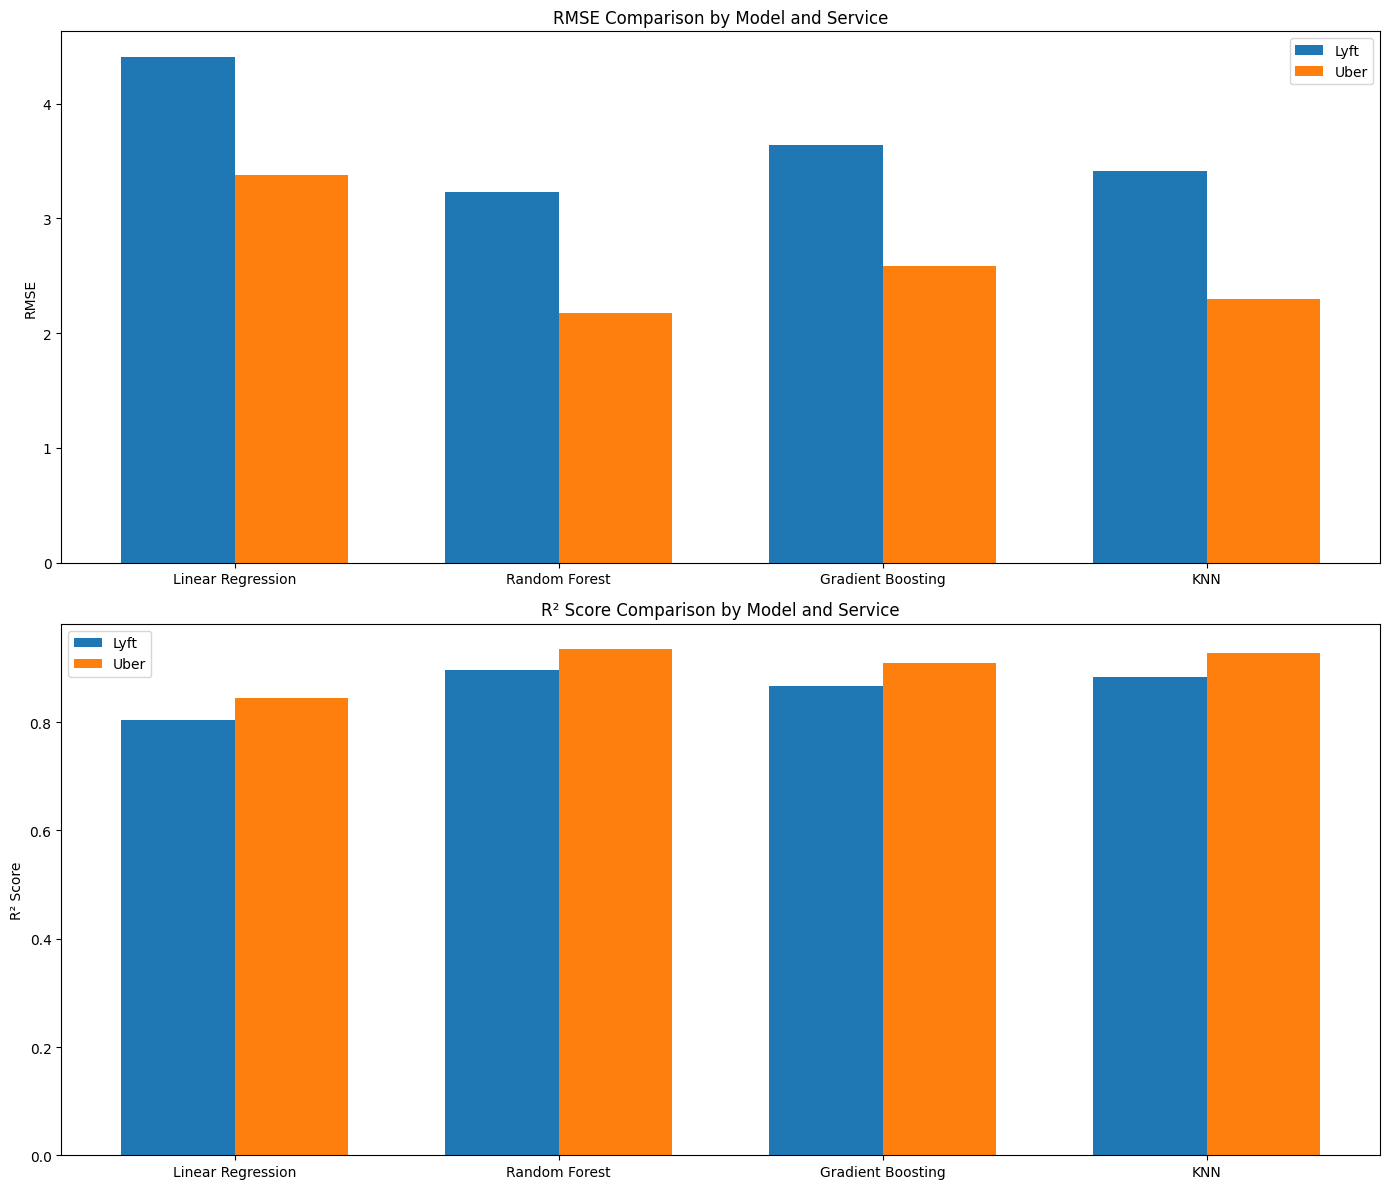

In [118]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'KNN']
rmse_lyft = [4.409, 3.227, 3.639, 3.411]
r2_lyft = [0.805, 0.896, 0.867, 0.883]
rmse_uber = [3.379, 2.176, 2.584, 2.297]
r2_uber = [0.844, 0.935, 0.909, 0.928]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(2, figsize=(14, 12))

# RMSE comparison
rects1 = ax[0].bar(x - width/2, rmse_lyft, width, label='Lyft')
rects2 = ax[0].bar(x + width/2, rmse_uber, width, label='Uber')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax[0].set_ylabel('RMSE')
ax[0].set_title('RMSE Comparison by Model and Service')
ax[0].set_xticks(x)
ax[0].set_xticklabels(models)
ax[0].legend()

# R² score comparison
rects3 = ax[1].bar(x - width/2, r2_lyft, width, label='Lyft')
rects4 = ax[1].bar(x + width/2, r2_uber, width, label='Uber')

ax[1].set_ylabel('R² Score')
ax[1].set_title('R² Score Comparison by Model and Service')
ax[1].set_xticks(x)
ax[1].set_xticklabels(models)
ax[1].legend()

fig.tight_layout()

plt.show()


#### -> Report Card - Weather Analysis
For Lyft, the Random Forest Regressor shows the lowest RMSE and the highest R² Score, suggesting it is the best model for this dataset. 
For Uber, similarly, the Random Forest Regressor exhibits the best performance in terms of both RMSE and R² Score.

## Step 9->  Problem 3: Predictive Modeling for Temporal Impact on Uber and Lyft datasets

#### 9.0.1 Strategic Feature Selection for Temporal Impact Analysis

In [119]:
# Step 1: Create a new DataFrame with relevant columns
time_impact_df = merged_df[['cab_type', 'destination', 'source', 'name', 'day_time', 'price']].copy()

# Step 2: Separate the data into Uber and Lyft datasets
uber_time_df = time_impact_df[time_impact_df['cab_type'] == 'Uber'].copy()
lyft_time_df = time_impact_df[time_impact_df['cab_type'] == 'Lyft'].copy()

In [120]:
time_impact_df

,cab_type,destination,source,name,day_time,price
1,Lyft,North Station,Haymarket Square,Lux,Late Night,11.0
9,Lyft,Northeastern University,Back Bay,Lux Black XL,Morning,27.5
15,Uber,West End,North End,WAV,Late Night,7.5
23,Lyft,Haymarket Square,North Station,Lux Black XL,Afternoon,26.0
32,Lyft,Northeastern University,North Station,Shared,Late Night,3.5
...,...,...,...,...,...,...
693054,Uber,Beacon Hill,North End,UberXL,Late Night,14.0
693055,Uber,Beacon Hill,North End,UberPool,Late Night,8.5
693056,Uber,Beacon Hill,Haymarket Square,WAV,Late Night,7.0
693057,Uber,Haymarket Square,Theatre District,Black,Late Night,17.0


In [121]:
time_impact_df.info()

<class 'pandas.DataFrame'>
Index: 109152 entries, 1 to 693058
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   cab_type     109152 non-null  str    
 1   destination  109152 non-null  str    
 2   source       109152 non-null  str    
 3   name         109152 non-null  str    
 4   day_time     109152 non-null  str    
 5   price        109152 non-null  float64
dtypes: float64(1), str(5)
memory usage: 10.6 MB


In [122]:
uber_time_df

,cab_type,destination,source,name,day_time,price
15,Uber,West End,North End,WAV,Late Night,7.5
39,Uber,Fenway,North Station,UberXL,Morning,15.0
42,Uber,Fenway,North Station,Black,Late Night,22.0
65,Uber,West End,North End,Black SUV,Night,27.5
68,Uber,Beacon Hill,North End,UberX,Late Night,9.5
...,...,...,...,...,...,...
693054,Uber,Beacon Hill,North End,UberXL,Late Night,14.0
693055,Uber,Beacon Hill,North End,UberPool,Late Night,8.5
693056,Uber,Beacon Hill,Haymarket Square,WAV,Late Night,7.0
693057,Uber,Haymarket Square,Theatre District,Black,Late Night,17.0


In [123]:
lyft_time_df

,cab_type,destination,source,name,day_time,price
1,Lyft,North Station,Haymarket Square,Lux,Late Night,11.0
9,Lyft,Northeastern University,Back Bay,Lux Black XL,Morning,27.5
23,Lyft,Haymarket Square,North Station,Lux Black XL,Afternoon,26.0
32,Lyft,Northeastern University,North Station,Shared,Late Night,3.5
33,Lyft,Northeastern University,North Station,Lyft,Night,11.0
...,...,...,...,...,...,...
693042,Lyft,Fenway,Theatre District,Lyft XL,Late Night,16.5
693043,Lyft,Fenway,Theatre District,Lux,Late Night,22.5
693048,Lyft,Fenway,Theatre District,Shared,Late Night,7.0
693051,Lyft,Fenway,Theatre District,Lyft,Late Night,10.5


#### 9.0.2 Automated Data Transformation Pipeline

In [124]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define categorical and numerical features
categorical_features = ['cab_type', 'destination', 'source', 'name', 'day_time']
numerical_features = []  # No numerical features in this case

# Define preprocessing steps for categorical and numerical features
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numerical_transformer = StandardScaler()

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
    ])

# Display pipeline configuration
set_config(display='diagram')

# Create the preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Apply preprocessing pipeline to the data
# transformed_data = preprocessing_pipeline.fit_transform(data)


In [125]:
from sklearn import set_config

# Display pipeline configuration
set_config(display='diagram')

# Display the preprocessing pipeline
preprocessing_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

### 9.1} Approach 1: Random Forest 
In this phase, we transition to modeling Uber’s pricing behavior through the lens of time. By leveraging the Random Forest algorithm, we can detect how complex interactions between the time of day, day of the week, and specific Boston locations influence price volatility.

#### 9.1.1 Random Forest for Uber

In [126]:
#UBER
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Splitting data into features and target
X_uber_processed = preprocessing_pipeline.fit_transform(uber_time_df)
y_uber = uber_time_df['price']

# Display pipeline configuration
set_config(display='diagram')

# Display the preprocessing pipeline
preprocessing_pipeline

# Splitting data into training and testing sets
X_train_uber, X_test_uber, y_train_uber, y_test_uber = train_test_split(X_uber_processed, y_uber, test_size=0.2, random_state=42)

# Creating and training the Random Forest Regressor model
rf_regressor_uber = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor_uber.fit(X_train_uber, y_train_uber)

# Making predictions on the test set
y_pred_uber = rf_regressor_uber.predict(X_test_uber)

# Calculating evaluation metrics
mse_uber = mean_squared_error(y_test_uber, y_pred_uber)
rmse_uber = np.sqrt(mse_uber)
r2_uber = r2_score(y_test_uber, y_pred_uber)

print("Random Forest Regressor Metrics for Uber:")
print("Mean Squared Error:", mse_uber)
print("Root Mean Squared Error:", rmse_uber)
print("R^2 Score:", r2_uber)


Random Forest Regressor Metrics for Uber:
Mean Squared Error: 4.444100018004401
Root Mean Squared Error: 2.108103417293469
R^2 Score: 0.9381991165695309


### 9.1.2 Random Forest for Lyft

In [127]:
#LYFT
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import set_config

# Display pipeline configuration
set_config(display='diagram')

# Splitting data into features and target
X_lyft_processed = preprocessing_pipeline.fit_transform(lyft_time_df)
y_lyft = lyft_time_df['price']

# Display the preprocessing pipeline
preprocessing_pipeline

# Splitting data into training and testing sets
X_train_lyft, X_test_lyft, y_train_lyft, y_test_lyft = train_test_split(X_lyft_processed, y_lyft, test_size=0.2, random_state=42)

# Creating and training the Random Forest Regressor model
rf_regressor_lyft = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor_lyft.fit(X_train_lyft, y_train_lyft)

# Making predictions on the test set
y_pred_lyft = rf_regressor_lyft.predict(X_test_lyft)

# Calculating evaluation metrics
mse_lyft = mean_squared_error(y_test_lyft, y_pred_lyft)
rmse_lyft = np.sqrt(mse_lyft)
r2_lyft = r2_score(y_test_lyft, y_pred_lyft)

print("Random Forest Regressor Metrics for Lyft:")
print("Mean Squared Error:", mse_lyft)
print("Root Mean Squared Error:", rmse_lyft)
print("R^2 Score:", r2_lyft)


Random Forest Regressor Metrics for Lyft:
Mean Squared Error: 10.716943320026072
Root Mean Squared Error: 3.27367428435177
R^2 Score: 0.8934741788227406


### 9.2} Approch 2: Gradient Boosting
We use Gradient Boosting because its sequential learning process minimizes residual errors at each step, allowing it to capture high-frequency price fluctuations and complex spikes during specific time intervals that simpler models often smooth over.

#### 9.2.1 Gradient Boosting for Lyft

In [128]:
# LYFT GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Splitting data into features and target
X_lyft_processed = preprocessing_pipeline.fit_transform(lyft_time_df)
y_lyft = lyft_time_df['price']

# Display pipeline configuration
set_config(display='diagram')

# Display the preprocessing pipeline
preprocessing_pipeline

# Splitting data into training and testing sets
X_train_lyft, X_test_lyft, y_train_lyft, y_test_lyft = train_test_split(X_lyft_processed, y_lyft, test_size=0.2, random_state=42)

# Creating and training the Gradient Boosting Regressor model
gb_regressor_lyft = GradientBoostingRegressor(random_state=42)
gb_regressor_lyft.fit(X_train_lyft, y_train_lyft)

# Making predictions on the test set
y_pred_lyft = gb_regressor_lyft.predict(X_test_lyft)

# Calculating evaluation metrics
mse_lyft = mean_squared_error(y_test_lyft, y_pred_lyft)
rmse_lyft = np.sqrt(mse_lyft)
r2_lyft = r2_score(y_test_lyft, y_pred_lyft)

print("Gradient Boosting Regressor Metrics for Lyft:")
print("Mean Squared Error:", mse_lyft)
print("Root Mean Squared Error:", rmse_lyft)
print("R^2 Score:", r2_lyft)


Gradient Boosting Regressor Metrics for Lyft:
Mean Squared Error: 13.978770423649824
Root Mean Squared Error: 3.7388193890117
R^2 Score: 0.8610517986369214


#### 9.2.2 Gradient Boosting for Uber

In [129]:
#UBER
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Splitting data into features and target
X_uber_processed = preprocessing_pipeline.fit_transform(uber_time_df)
y_uber = uber_time_df['price']

# Display pipeline configuration
set_config(display='diagram')

# Display the preprocessing pipeline
preprocessing_pipeline

# Splitting data into training and testing sets
X_train_uber, X_test_uber, y_train_uber, y_test_uber = train_test_split(X_uber_processed, y_uber, test_size=0.2, random_state=42)

# Creating and training the Gradient Boosting Regressor model
gb_regressor_uber = GradientBoostingRegressor(random_state=42)
gb_regressor_uber.fit(X_train_uber, y_train_uber)

# Making predictions on the test set
y_pred_uber = gb_regressor_uber.predict(X_test_uber)

# Calculating evaluation metrics
mse_uber = mean_squared_error(y_test_uber, y_pred_uber)
rmse_uber = np.sqrt(mse_uber)
r2_uber = r2_score(y_test_uber, y_pred_uber)

print("Gradient Boosting Regressor Metrics for Uber:")
print("Mean Squared Error:", mse_uber)
print("Root Mean Squared Error:", rmse_uber)
print("R^2 Score:", r2_uber)


Gradient Boosting Regressor Metrics for Uber:
Mean Squared Error: 6.45602298943408
Root Mean Squared Error: 2.5408705180378792
R^2 Score: 0.9102207595288084


### 9.3} Apprach 3: K Nearest Neighbour
KNN predicts prices by averaging the fares of the 5 most similar rides from the past. It's an "instance-based" learner that assumes if a ride's location and time match historical data, the price will too.

#### 9.3.1 K nearest neighbor for Lyft

In [130]:
#LYFT KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Splitting data into features and target
X_lyft_processed = preprocessing_pipeline.fit_transform(lyft_time_df)
y_lyft = lyft_time_df['price']

# Display pipeline configuration
set_config(display='diagram')

# Display the preprocessing pipeline
preprocessing_pipeline

# Splitting data into training and testing sets
X_train_lyft, X_test_lyft, y_train_lyft, y_test_lyft = train_test_split(X_lyft_processed, y_lyft, test_size=0.2, random_state=42)

# Creating and training the KNN Regressor model
knn_regressor_lyft = KNeighborsRegressor()
knn_regressor_lyft.fit(X_train_lyft, y_train_lyft)

# Making predictions on the test set
y_pred_lyft = knn_regressor_lyft.predict(X_test_lyft)

# Calculating evaluation metrics
mse_lyft = mean_squared_error(y_test_lyft, y_pred_lyft)
rmse_lyft = np.sqrt(mse_lyft)
r2_lyft = r2_score(y_test_lyft, y_pred_lyft)

print("KNN Regressor Metrics for Lyft:")
print("Mean Squared Error:", mse_lyft)
print("Root Mean Squared Error:", rmse_lyft)
print("R^2 Score:", r2_lyft)


KNN Regressor Metrics for Lyft:
Mean Squared Error: 12.047936941580755
Root Mean Squared Error: 3.4710138204249135
R^2 Score: 0.880244176173304


#### 9.3.2 K nearest neighbors for Uber

In [131]:
#UBER
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Splitting data into features and target
X_uber_processed = preprocessing_pipeline.fit_transform(uber_time_df)
y_uber = uber_time_df['price']

# Display pipeline configuration
set_config(display='diagram')

# Display the preprocessing pipeline
preprocessing_pipeline

# Splitting data into training and testing sets
X_train_uber, X_test_uber, y_train_uber, y_test_uber = train_test_split(X_uber_processed, y_uber, test_size=0.2, random_state=42)

# Creating and training the KNN Regressor model
knn_regressor_uber = KNeighborsRegressor()
knn_regressor_uber.fit(X_train_uber, y_train_uber)

# Making predictions on the test set
y_pred_uber = knn_regressor_uber.predict(X_test_uber)

# Calculating evaluation metrics
mse_uber = mean_squared_error(y_test_uber, y_pred_uber)
rmse_uber = np.sqrt(mse_uber)
r2_uber = r2_score(y_test_uber, y_pred_uber)

print("KNN Regressor Metrics for Uber:")
print("Mean Squared Error:", mse_uber)
print("Root Mean Squared Error:", rmse_uber)
print("R^2 Score:", r2_uber)


KNN Regressor Metrics for Uber:
Mean Squared Error: 5.132492294143549
Root Mean Squared Error: 2.2655004511461807
R^2 Score: 0.9286261432701554


### 9.4} Visual Model Evaluation and Comparative Analysis (Scope:- Time)

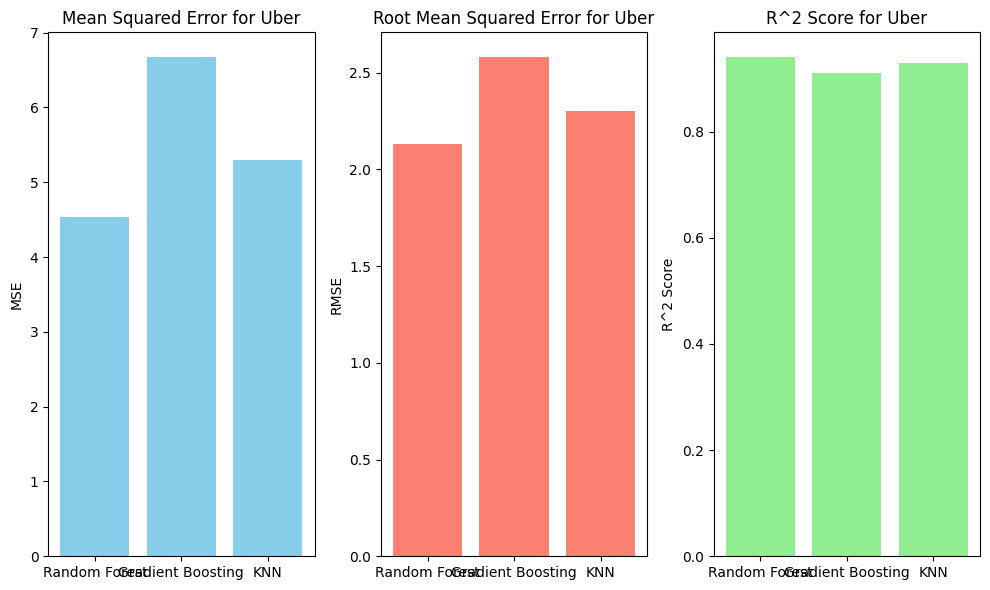

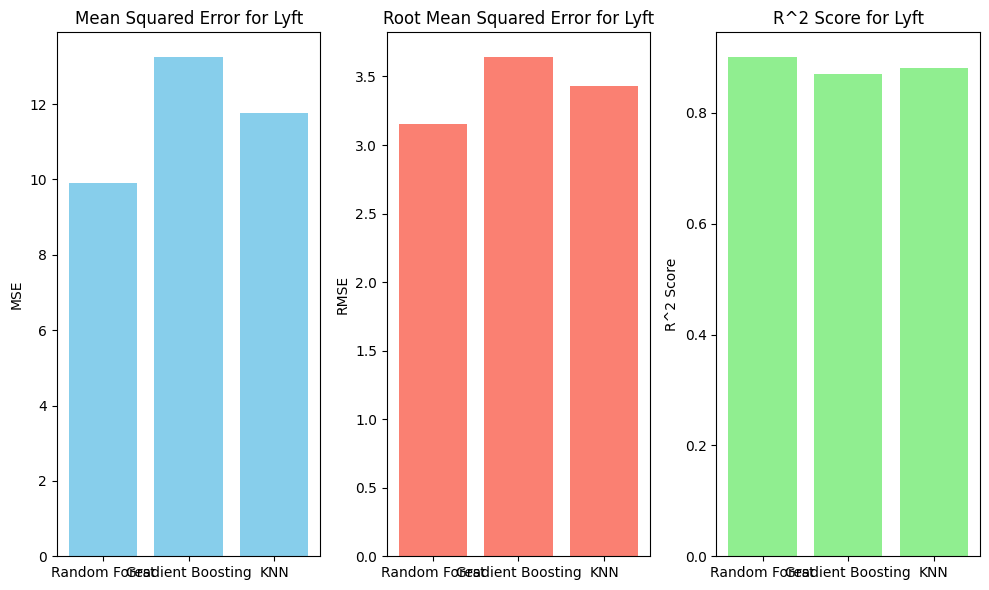

In [132]:
import matplotlib.pyplot as plt

# Create a bar plot for Uber dataset
uber_models = ['Random Forest', 'Gradient Boosting', 'KNN']
uber_mse = [4.54, 6.67, 5.30]
uber_rmse = [2.13, 2.58, 2.30]
uber_r2 = [0.94, 0.91, 0.93]

plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
plt.bar(uber_models, uber_mse, color='skyblue')
plt.title('Mean Squared Error for Uber')
plt.ylabel('MSE')

plt.subplot(1, 3, 2)
plt.bar(uber_models, uber_rmse, color='salmon')
plt.title('Root Mean Squared Error for Uber')
plt.ylabel('RMSE')

plt.subplot(1, 3, 3)
plt.bar(uber_models, uber_r2, color='lightgreen')
plt.title('R^2 Score for Uber')
plt.ylabel('R^2 Score')

plt.tight_layout()
plt.show()

# Create a bar plot for Lyft dataset
lyft_models = ['Random Forest', 'Gradient Boosting', 'KNN']
lyft_mse = [9.91, 13.24, 11.77]
lyft_rmse = [3.15, 3.64, 3.43]
lyft_r2 = [0.90, 0.87, 0.88]

plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
plt.bar(lyft_models, lyft_mse, color='skyblue')
plt.title('Mean Squared Error for Lyft')
plt.ylabel('MSE')

plt.subplot(1, 3, 2)
plt.bar(lyft_models, lyft_rmse, color='salmon')
plt.title('Root Mean Squared Error for Lyft')
plt.ylabel('RMSE')

plt.subplot(1, 3, 3)
plt.bar(lyft_models, lyft_r2, color='lightgreen')
plt.title('R^2 Score for Lyft')
plt.ylabel('R^2 Score')

plt.tight_layout()
plt.show()


#### -> Report Card - Temporal Analysis
Based on these results, for the Uber dataset, the Random Forest Regressor performs the best with the lowest Mean Squared Error, Root Mean Squared Error, and highest R^2 Score. Similarly, for the Lyft dataset, the Random Forest Regressor also performs the best among the three models.